In [3]:
  # Install
!pip install torch torchvision numpy matplotlib scipy -q
!pip install datasets transformers -q   # HuggingFace
!pip install adabelief-pytorch -q
!pip install sacrebleu -q               # BLEU score evaluation for seq2seq
print("All packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.8 MB/s eta 0:00:00
All packages ready.


In [4]:
import os, math, time, json, warnings, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer
from datetime import datetime
from scipy import stats
import sacrebleu as sb
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Multi30k Data Loader

Downloads the Multi30k English to German translation dataset via HuggingFace `datasets`.
Builds separate source (English) and target (German) vocabularies from the training
set only. Tokenises with simple whitespace/punctuation splitting and pads/truncates to a
fixed sequence length. All four special tokens are reserved:

```
0 = <PAD>   1 = <SOS>   2 = <EOS>   3 = <UNK>
```

No pretrained embeddings — the model learns both embedding matrices from scratch so
the optimizer comparison is fair across all baselines.

In [5]:
from datasets import load_dataset
from collections import Counter


# Tokeniser
def basic_tokenize(text):
    """Lowercase + split on whitespace and punctuation."""
    text = text.lower().strip()
    text = re.sub(r'([.!?,;:])', r' \1 ', text)
    return text.split()


# Vocabulary
class Vocabulary:
    """
    Maps tokens to integer IDs.
    Reserves: 0=<PAD>, 1=<SOS>, 2=<EOS>, 3=<UNK>.
    """
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self._freq    = {}

    def build(self, sentences):
        for sent in sentences:
            for tok in basic_tokenize(sent):
                self._freq[tok] = self._freq.get(tok, 0) + 1
        added = 0
        for word, freq in self._freq.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
                added += 1
        rare = sum(1 for c in self._freq.values() if c < self.min_freq)
        print(f'[vocab] size={len(self.word2idx):,}  '
              f'(added={added:,}, dropped {rare:,} rare tokens, min_freq={self.min_freq})')
        return self

    def encode(self, sentence, max_len):
        """Encode: <SOS> + tokens + <EOS>, padded/truncated to max_len."""
        tokens = basic_tokenize(sentence)
        ids    = [self.word2idx.get(t, self.UNK) for t in tokens]
        ids    = [self.SOS] + ids[:max_len - 2] + [self.EOS]
        ids   += [self.PAD] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        """Convert id list back to string, stopping at EOS."""
        tokens = []
        for i in ids:
            if i == self.EOS:
                break
            if i not in (self.PAD, self.SOS):
                tokens.append(self.idx2word.get(i, '<UNK>'))
        return ' '.join(tokens) if tokens else '<empty>'

    def __len__(self):
        return len(self.word2idx)


# Dataset
class Multi30kDataset(Dataset):
    """
    HuggingFace bentrevett/multi30k => paired (src_ids, tgt_ids) tensors.
    src = English, tgt = German.
    """
    def __init__(self, pairs, src_vocab, tgt_vocab, src_max, tgt_max):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.src_max   = src_max
        self.tgt_max   = tgt_max

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        src_ids = self.src_vocab.encode(src_text, self.src_max)
        tgt_ids = self.tgt_vocab.encode(tgt_text, self.tgt_max)
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
        )


# Loader factory
def get_multi30k_loaders(batch_size=64, src_max=64, tgt_max=64, min_freq=2, num_workers=2):
    """
    Downloads Multi30k (en->de), builds vocabularies, returns DataLoaders.
    Returns: train_loader, val_loader, test_loader, src_vocab, tgt_vocab
    """
    print('[data] Downloading Multi30k from HuggingFace (bentrevett/multi30k)...')
    ds = load_dataset('bentrevett/multi30k')

    def get_pairs(split):
        return [(row['en'], row['de']) for row in ds[split]]

    train_pairs = get_pairs('train')
    val_pairs   = get_pairs('validation')
    test_pairs  = get_pairs('test')
    print(f'[data] Train: {len(train_pairs):,}  Val: {len(val_pairs):,}  Test: {len(test_pairs):,}')

    print('[vocab] Building source (English) vocabulary...')
    src_vocab = Vocabulary(min_freq=min_freq).build([p[0] for p in train_pairs])
    print('[vocab] Building target (German) vocabulary...')
    tgt_vocab = Vocabulary(min_freq=min_freq).build([p[1] for p in train_pairs])

    make = lambda pairs: Multi30kDataset(pairs, src_vocab, tgt_vocab, src_max, tgt_max)
    train_loader = DataLoader(make(train_pairs), batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(make(val_pairs),   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(make(test_pairs),  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f'[data] Src vocab: {len(src_vocab):,}  Tgt vocab: {len(tgt_vocab):,}')
    print(f'[data] Src max_len: {src_max}  Tgt max_len: {tgt_max}')
    return train_loader, val_loader, test_loader, src_vocab, tgt_vocab


# Quick smoke test
_tl, _vl, _tel, _src_vocab, _tgt_vocab = get_multi30k_loaders(batch_size=4, num_workers=0)
_src_batch, _tgt_batch = next(iter(_tl))
assert _src_batch.shape == (4, 64), f'Expected (4,64), got {_src_batch.shape}'
assert _tgt_batch.shape == (4, 64), f'Expected (4,64), got {_tgt_batch.shape}'
print(f'Loader OK -- src {list(_src_batch.shape)}, tgt {list(_tgt_batch.shape)}')
del _tl, _vl, _tel

[data] Downloading Multi30k from HuggingFace (bentrevett/multi30k)...


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

[data] Train: 29,000  Val: 1,014  Test: 1,000
[vocab] Building source (English) vocabulary...
[vocab] size=5,970  (added=5,966, dropped 4,557 rare tokens, min_freq=2)
[vocab] Building target (German) vocabulary...
[vocab] size=7,811  (added=7,807, dropped 10,979 rare tokens, min_freq=2)
[data] Src vocab: 5,970  Tgt vocab: 7,811
[data] Src max_len: 64  Tgt max_len: 64
Loader OK -- src [4, 64], tgt [4, 64]


## Model -- Encoder-Decoder Transformer

A standard seq2seq Transformer for English to German translation.

```
src tokens -> Embedding(src_vocab, 256) + PositionalEncoding
                |
           TransformerEncoder (3 layers, 8 heads, FFN=1024)
                |  memory  (cross-attention source)
tgt tokens -> Embedding(tgt_vocab, 256) + PositionalEncoding
                |
           TransformerDecoder (3 layers, 8 heads, causal mask + cross-attn)
                |
           Linear(256 -> tgt_vocab_size)  ->  logits
```

Key design choices:
- **Pre-LayerNorm** (`norm_first=True`) -- more stable than post-norm.
- **Sinusoidal positional encoding** -- standard for translation.
- **Causal mask** in decoder -- prevents attending to future tokens.
- **Greedy decoding** at eval -- no teacher forcing; autoregressive generation.

Training uses **teacher forcing**: decoder input = `tgt[:, :-1]`, target = `tgt[:, 1:]`.

In [6]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al. 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class EncoderDecoderTransformer(nn.Module):
    """
    Encoder-Decoder Transformer for seq2seq translation.
    Training:   teacher forcing  -- tgt[:, :-1] as decoder input, tgt[:, 1:] as target
    Evaluation: greedy_decode()  -- autoregressive, no ground-truth tokens fed
    """
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=256, n_heads=8, n_enc_layers=3, n_dec_layers=3,
                 ffn_dim=1024, max_len=128, dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.scale   = math.sqrt(d_model)

        # Embeddings
        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Transformer core (pre-norm = more stable)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, n_enc_layers, norm=nn.LayerNorm(d_model))
        self.decoder = nn.TransformerDecoder(dec_layer, n_dec_layers, norm=nn.LayerNorm(d_model))

        # Output projection
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _src_pad_mask(self, src):
        return src == self.pad_idx

    def _tgt_pad_mask(self, tgt):
        return tgt == self.pad_idx

    def _causal_mask(self, size, device):
        """Upper-triangular mask: decoder cannot attend to future tokens."""
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def encode(self, src):
        src_pad = self._src_pad_mask(src)
        emb     = self.pos_enc(self.src_emb(src) * self.scale)
        return self.encoder(emb, src_key_padding_mask=src_pad), src_pad

    def forward(self, src, tgt):
        """
        src : (B, S)  source token ids
        tgt : (B, T)  target token ids (already shifted: tgt[:, :-1])
        returns logits (B, T, tgt_vocab_size)
        """
        memory, src_pad = self.encode(src)
        tgt_pad         = self._tgt_pad_mask(tgt)
        tgt_causal      = self._causal_mask(tgt.size(1), tgt.device)
        tgt_emb         = self.pos_enc(self.tgt_emb(tgt) * self.scale)
        out = self.decoder(
            tgt_emb, memory,
            tgt_mask=tgt_causal,
            tgt_key_padding_mask=tgt_pad,
            memory_key_padding_mask=src_pad,
        )
        return self.fc_out(out)

    @torch.no_grad()
    def greedy_decode(self, src, sos_idx, eos_idx, max_len=64):
        """
        Autoregressive greedy decoding (no teacher forcing).
        src: (B, S)
        Returns: list of B decoded token-id lists (stops at EOS).
        """
        device  = src.device
        B       = src.size(0)
        memory, src_pad = self.encode(src)
        ys      = torch.full((B, 1), sos_idx, dtype=torch.long, device=device)
        done    = torch.zeros(B, dtype=torch.bool, device=device)
        decoded = [[] for _ in range(B)]

        for _ in range(max_len):
            tgt_emb     = self.pos_enc(self.tgt_emb(ys) * self.scale)
            causal_mask = self._causal_mask(ys.size(1), device)
            out         = self.decoder(tgt_emb, memory,
                                       tgt_mask=causal_mask,
                                       memory_key_padding_mask=src_pad)
            logits      = self.fc_out(out[:, -1, :])
            next_tok    = logits.argmax(-1)

            for i in range(B):
                if not done[i]:
                    if next_tok[i].item() == eos_idx:
                        done[i] = True
                    else:
                        decoded[i].append(next_tok[i].item())
            if done.all():
                break
            ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)

        return decoded


# Sanity check
_model = EncoderDecoderTransformer(
    src_vocab_size=len(_src_vocab),
    tgt_vocab_size=len(_tgt_vocab),
).to(device)
n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'EncoderDecoderTransformer: {n_params/1e6:.2f}M params')

_src = _src_batch.to(device)
_tgt = _tgt_batch.to(device)
with torch.no_grad():
    _logits = _model(_src, _tgt[:, :-1])
assert _logits.shape == (4, 63, len(_tgt_vocab)), f'Shape mismatch: {_logits.shape}'
print(f'Forward (teacher-forcing) OK -- logits {list(_logits.shape)}')

_decoded = _model.greedy_decode(_src, Vocabulary.SOS, Vocabulary.EOS, max_len=10)
print(f'Greedy decode OK -- {len(_decoded)} sequences, first has {len(_decoded[0])} tokens')
del _model, _src, _tgt, _logits, _decoded

EncoderDecoderTransformer: 11.07M params
Forward (teacher-forcing) OK -- logits [4, 63, 7811]
Greedy decode OK -- 4 sequences, first has 10 tokens


## PhaseAwareOptimizer

Identical implementation to the IMDB notebook — no changes needed.

In [ ]:
from torch.optim import Optimizer
import math


class PhaseAwareOptimizer(Optimizer):
    """
    Phase-Aware Optimizer v5 — Flat-Minima Edition.

    Key fixes over v4 (based on empirical results showing sharp minima):

    1. NOISE FLOOR (noise_min > 0)
       v4 let noise decay to ~0 by phi=0.9 → model locked into sharp basins.
       v5 keeps noise >= noise_min throughout. This maintains gentle exploration
       pressure in late training, preventing the optimizer from getting stuck
       in narrow valleys that don't generalise.

    2. SAM-LITE (sharpness-aware gradient correction)
       Before the Adam update, we add a small gradient perturbation:
           g_corrected = g + sam_coeff * g / (||g|| + eps)
       This is a single forward-pass approximation of SAM's perturbation step.
       It biases the update direction AWAY from sharp curvature without
       requiring a second backward pass (2x cost of full SAM).
       sam_coeff decays with phi so it's strong early, gentle late.

    3. DECOUPLED WEIGHT DECAY (AdamW-style)
       v4 added weight_decay into the gradient (L2 regularisation).
       That couples regularisation with the adaptive scaling, which
       distorts the update direction. v5 applies weight decay directly
       to parameters AFTER the Adam step, identical to AdamW.
       This is the single biggest reason AdamW beats Adam on generalisation.

    4. DYNAMIC PHASE using loss plateau detection
       phi now incorporates a loss-plateau signal:
       when val loss stops improving, phi is nudged upward faster,
       triggering earlier stabilisation. This makes the optimizer
       genuinely adaptive rather than just time-scheduled.

    5. MOMENTUM SCHEDULE (β1 peaks mid-training)
       Fixed β1 is suboptimal. v5 uses:
           β1(phi) = β1_min + (β1_max - β1_min) * sin(pi * phi)
       β1_min early (exploration, don't lock direction too early)
       β1_max mid   (stabilise trajectory when loss is dropping fast)
       β1_min late  (fine-tune, allow local adjustments)
    """

    def __init__(self, params,
                 # LR schedule
                 lr_max=0.001, lr_min=2e-5,
                 warmup_ratio=0.03, hold_frac=0.12,
                 # Adam core
                 beta1=0.9, beta1_max=0.95,
                 beta2=0.999, eps=1e-8,
                 # Noise (v5: floor prevents sharp minima)
                 noise_max=0.04, noise_min=0.008,
                 # SAM-lite (sharpness correction)
                 sam_coeff=0.015,
                 # Regularisation (decoupled)
                 weight_decay=0.01,
                 # Training control
                 total_steps=10000, max_grad_norm=1.0,
                 # Phase type
                 phase_type='adaptive',
                 var_window=50, time_weight=0.7):

        defaults = dict(
            lr_max=lr_max, lr_min=lr_min,
            warmup_ratio=warmup_ratio, hold_frac=hold_frac,
            beta1=beta1, beta1_max=beta1_max,
            beta2=beta2, eps=eps,
            noise_max=noise_max, noise_min=noise_min,
            sam_coeff=sam_coeff,
            weight_decay=weight_decay,
            total_steps=total_steps, max_grad_norm=max_grad_norm,
            phase_type=phase_type,
            var_window=var_window, time_weight=time_weight,
        )
        super().__init__(params, defaults)
        self.step_count         = 0
        self.phase              = 0.0
        self.current_lr         = 0.0
        self.current_noise      = 0.0
        self._grad_norm_history = []
        self._initial_var       = None
        self._loss_history      = []   # for plateau detection

    # ── Phase variable ────────────────────────────────────────────────────
    def _phi_time(self):
        return min(1.0, self.step_count / max(1, self.defaults['total_steps']))

    def _phi(self, avg_grad_norm):
        phi_t = self._phi_time()
        if self.defaults['phase_type'] == 'time':
            return phi_t

        # Gradient variance component (original)
        w = self.defaults['var_window']
        self._grad_norm_history.append(avg_grad_norm)
        if len(self._grad_norm_history) > w * 4:
            self._grad_norm_history = self._grad_norm_history[-w * 2:]
        if len(self._grad_norm_history) < w:
            return phi_t
        recent   = self._grad_norm_history[-w:]
        mean_r   = sum(recent) / w
        var_now  = sum((x - mean_r) ** 2 for x in recent) / w
        if self._initial_var is None:
            self._initial_var = max(var_now, 1e-12)
        norm_var = min(1.0, var_now / max(self._initial_var, 1e-12))

        # Loss plateau component: if loss stopped improving, push phi higher
        # (signals: time to switch from exploration to convergence)
        plateau_signal = 0.0
        if len(self._loss_history) >= 2 * w:
            recent_loss = self._loss_history[-w:]
            older_loss  = self._loss_history[-2*w:-w]
            mean_recent = sum(recent_loss) / w
            mean_older  = sum(older_loss) / w
            # If recent loss is not improving much, plateau_signal → 1
            relative_improvement = max(0.0, (mean_older - mean_recent) / max(mean_older, 1e-8))
            plateau_signal = max(0.0, 1.0 - relative_improvement * 20.0)

        tw = self.defaults['time_weight']
        # Combine: time + variance stabilisation + plateau
        phi_dynamic = (tw * phi_t
                       + 0.15 * (1.0 - norm_var)
                       + 0.15 * plateau_signal)
        return min(1.0, max(phi_t, phi_dynamic))

    def log_loss(self, loss_val):
        """Call each step with the current batch loss for plateau detection."""
        self._loss_history.append(loss_val)
        if len(self._loss_history) > 200:
            self._loss_history = self._loss_history[-100:]

    # ── LR schedule ──────────────────────────────────────────────────────
    def _lr(self, phi):
        """
        warmup → plateau at lr_max → cosine decay to lr_min
        Stage boundaries controlled by warmup_ratio and hold_frac.
        """
        d  = self.defaults
        wr = d['warmup_ratio']
        hr = wr + d['hold_frac']
        if phi < wr:
            return d['lr_max'] * (phi / max(wr, 1e-8))
        if phi < hr:
            return d['lr_max']
        adj = (phi - hr) / max(1.0 - hr, 1e-8)
        return d['lr_min'] + 0.5 * (d['lr_max'] - d['lr_min']) * (1.0 + math.cos(math.pi * adj))

    # ── β1 schedule ───────────────────────────────────────────────────────
    def _beta1(self, phi):
        """
        β1 follows a sine arch: starts at beta1, peaks at beta1_max mid-training,
        returns to beta1 at end. This gives:
          early:  moderate momentum (don't lock direction too early)
          mid:    strong momentum   (stabilise trajectory when loss drops fast)
          late:   moderate momentum (allow fine-grained local adjustments)
        """
        d = self.defaults
        b_min = d['beta1']
        b_max = d['beta1_max']
        return b_min + (b_max - b_min) * math.sin(math.pi * phi)

    # ── Noise (v5: floor — never zero) ───────────────────────────────────
    def _noise_scale(self, phi, rms_u):
        """
        v4: noise → 0 at end → sharp minima
        v5: noise → noise_min at end → gentle late-training flatness pressure
        Linear decay from noise_max to noise_min, scaled by RMS of update.
        """
        d = self.defaults
        frac = d['noise_min'] + (d['noise_max'] - d['noise_min']) * (1.0 - phi)
        return frac * rms_u

    # ── Cauchy noise ──────────────────────────────────────────────────────
    def _cauchy(self, shape, device):
        u = torch.rand(shape, device=device) - 0.5
        return torch.clamp(torch.tan(math.pi * u), -3.0, 3.0)

    # ── Main step ─────────────────────────────────────────────────────────
    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self.step_count += 1
        d = self.defaults

        # ── Gradient clipping ─────────────────────────────────────────────
        raw_norms = [p.grad.norm().item()
                     for g in self.param_groups
                     for p in g['params'] if p.grad is not None]
        avg_grad_norm = sum(raw_norms) / max(len(raw_norms), 1)
        if d['max_grad_norm'] > 0:
            all_p = [p for g in self.param_groups for p in g['params']
                     if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, d['max_grad_norm'])

        # ── Phase, LR, β1 ─────────────────────────────────────────────────
        phi = self._phi(avg_grad_norm)
        lr  = self._lr(phi)
        b1  = self._beta1(phi)
        self.phase, self.current_lr = phi, lr

        b2, eps = d['beta2'], d['eps']
        t       = self.step_count
        bc1     = 1.0 - b1 ** t   # bias correction — recomputed each step since b1 changes
        bc2     = 1.0 - b2 ** t

        # SAM-lite coefficient: strong early, fades with phase
        sam_c = d['sam_coeff'] * (1.0 - phi * 0.8)   # 100%→20% of sam_coeff

        noise_log = 0.0

        for group in self.param_groups:
            wd = group['weight_decay']
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data

                # ── SAM-lite: sharpness-aware gradient correction ──────────
                # Adds a small perturbation in the gradient direction,
                # scaled by sam_c / (||g|| + eps).
                # Effect: pushes update away from sharp curvature.
                # Single-pass (no extra forward/backward needed).
                if sam_c > 1e-8:
                    g_norm = grad.norm().add_(eps)
                    grad = grad + sam_c * grad / g_norm

                # ── Adam moment updates ────────────────────────────────────
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['m']    = torch.zeros_like(p)
                    state['v']    = torch.zeros_like(p)

                m, v = state['m'], state['v']
                m.mul_(b1).add_(grad, alpha=1.0 - b1)
                v.mul_(b2).addcmul_(grad, grad, value=1.0 - b2)

                m_hat = m / bc1
                v_hat = v / bc2
                u_hat = m_hat / v_hat.sqrt().add_(eps)

                # ── Adam parameter update ──────────────────────────────────
                p.data.add_(u_hat, alpha=-lr)

                # ── Decoupled weight decay (AdamW-style) ──────────────────
                # Applied AFTER Adam step, not inside gradient.
                # This is why AdamW beats Adam: the decay is not distorted
                # by the adaptive scaling of v_hat.
                if wd != 0.0:
                    p.data.mul_(1.0 - lr * wd)

                # ── Cauchy tunneling noise (v5: floor prevents dying) ──────
                n_elem     = u_hat.numel()
                rms_u      = u_hat.norm().item() / math.sqrt(max(n_elem, 1))
                noise_scale = self._noise_scale(phi, rms_u)
                noise_log   = noise_scale
                if noise_scale > 1e-12:
                    xi = self._cauchy(p.data.shape, p.data.device)
                    p.data.add_(xi, alpha=lr * noise_scale)

                state['step'] += 1

        self.current_noise = lr * noise_log
        return loss

    def get_current_state(self):
        return {
            'phase': self.phase,
            'lr':    self.current_lr,
            'noise': self.current_noise,
            'step':  self.step_count,
        }


print("PhaseAwareOptimizer v5 defined.")
print("  Changes vs v4:")
print("  [1] noise_min floor — prevents sharp minima trapping")
print("  [2] SAM-lite — sharpness-aware correction, no extra backward pass")
print("  [3] Decoupled weight decay (AdamW-style) — biggest generalisation fix")
print("  [4] Dynamic phi with loss plateau signal")
print("  [5] beta1 schedule: sine arch (medium -> high -> medium)")


## Baseline Optimizers

AdaBelief, SAM, and Lion -- identical to the IMDB notebook.

In [ ]:
# AdaBelief
class AdaBelief(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-16,
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas'];  eps = group['eps']
            lr = group['lr'];          wd  = group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                if wd != 0: g = g.add(p.data, alpha=wd)
                st = self.state[p]
                if len(st) == 0:
                    st['step'] = 0
                    st['m']    = torch.zeros_like(p)
                    st['s']    = torch.zeros_like(p)
                st['step'] += 1;  t = st['step'];  m, s = st['m'], st['s']
                m.mul_(b1).add_(g, alpha=1 - b1)
                surprise = (g - m).pow(2).add_(eps)
                s.mul_(b2).add_(surprise, alpha=1 - b2)
                m_hat = m / (1 - b1 ** t);  s_hat = s / (1 - b2 ** t)
                p.data.addcdiv_(m_hat, s_hat.sqrt().add_(eps), value=-lr)
        return loss


# SAM
class SAM(optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, **base_kwargs):
        super().__init__(params, dict(rho=rho))
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.rho            = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                self.state[p]['old_p'] = p.data.clone()
                p.data.add_(p.grad, alpha=scale)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.data = self.state[p]['old_p']
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def step(self, closure=None):
        raise NotImplementedError('SAM requires explicit first_step / second_step calls.')

    def _grad_norm(self):
        norms = [p.grad.norm(2) for g in self.param_groups
                 for p in g['params'] if p.grad is not None]
        return torch.stack(norms).norm(2)


# Lion
class Lion(optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0,
                 max_grad_norm=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay,
                                      max_grad_norm=max_grad_norm))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas'];  lr = group['lr'];  wd = group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                st = self.state[p]
                if len(st) == 0: st['m'] = torch.zeros_like(p)
                m = st['m']
                c = b1 * m + (1 - b1) * g
                p.data.add_(torch.sign(c) + wd * p.data, alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss


print('All baseline optimizers defined (AdaBelief, SAM, Lion).')

All baseline optimizers defined (AdaBelief, SAM, Lion).


## Training Loop -- Seq2Seq

The training loop for seq2seq differs from classification in two key ways:

**1. Teacher forcing during training** -- ground-truth target tokens (shifted right)
are fed as decoder input. Prevents error accumulation early in training.
```
input  = tgt[:, :-1]   # <SOS> w1 w2 ... w_{n-1}
target = tgt[:, 1:]    # w1 w2 ... w_{n-1} <EOS>
```

**2. Greedy decoding during evaluation** -- no ground truth is fed; the model
generates token-by-token. BLEU score is computed vs. references.

**Early stopping** (patience=5) is applied for AdamW, RAdam, and Lion to save
GPU time -- training stops if val BLEU does not improve for 5 consecutive epochs.

In [ ]:
import sacrebleu as sb

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Helper: token ids -> sentence string
def ids_to_sentence(ids, vocab):
    tokens = []
    for i in ids:
        if i == Vocabulary.EOS: break
        if i not in (Vocabulary.PAD, Vocabulary.SOS):
            tokens.append(vocab.idx2word.get(i, '<UNK>'))
    return ' '.join(tokens) if tokens else '<empty>'


# ─── Enhanced training epoch ─────────────────────────────────────────────────
# Returns: (avg_loss, avg_grad_norm, loss_oscillation)
#   avg_grad_norm   = mean ||g|| across batches   (logged per epoch)
#   loss_oscillation = std of per-batch losses     (stability proxy)
def train_epoch_seq2seq(model, loader, optimizer, criterion, device,
                        max_grad_norm=0.5):
    model.train()
    batch_losses    = []
    batch_grad_norms = []

    for src, tgt in loader:
        src = src.to(device); tgt = tgt.to(device)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        optimizer.zero_grad()
        logits = model(src, tgt_in)
        loss   = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()

        # ── Gradient norm (before clipping) ──────────────────────────────────
        grad_norm = sum(
            p.grad.detach().norm().item() ** 2
            for p in model.parameters() if p.grad is not None
        ) ** 0.5
        batch_grad_norms.append(grad_norm)

        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_loss      = float(np.mean(batch_losses))
    avg_grad_norm = float(np.mean(batch_grad_norms))
    oscillation   = float(np.std(batch_losses))   # loss stability within epoch
    return avg_loss, avg_grad_norm, oscillation


# ─── Evaluation epoch (greedy decode -> BLEU) ────────────────────────────────
def eval_epoch_seq2seq(model, loader, device, tgt_vocab_obj, max_decode_len=64):
    model.eval()
    hypotheses, references = [], []
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)
            decoded = model.greedy_decode(src, Vocabulary.SOS, Vocabulary.EOS,
                                          max_len=max_decode_len)
            for i in range(src.size(0)):
                hypotheses.append(ids_to_sentence(decoded[i], tgt_vocab_obj))
                references.append(ids_to_sentence(tgt[i].tolist(), tgt_vocab_obj))
    return sb.corpus_bleu(hypotheses, [references]).score


# ─── Sharpness measurement ────────────────────────────────────────────────────
# Perturbs weights with Gaussian noise and measures loss increase.
# sharpness = mean(perturbed_loss) - baseline_loss
# Higher sharpness -> sharper minima -> worse generalisation.
def measure_sharpness(model, loader, criterion, device,
                      noise_std=0.01, n_perturbations=5, n_batches=10):
    model.eval()
    original_params = [p.data.clone() for p in model.parameters()]

    def _eval_loss():
        total, cnt = 0.0, 0
        with torch.no_grad():
            for src, tgt in loader:
                src, tgt = src.to(device), tgt.to(device)
                logits = model(src, tgt[:, :-1])
                loss   = criterion(
                    logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
                total += loss.item(); cnt += 1
                if cnt >= n_batches: break
        return total / cnt

    baseline_loss = _eval_loss()

    perturbed = []
    for _ in range(n_perturbations):
        with torch.no_grad():
            for p, orig in zip(model.parameters(), original_params):
                p.data.copy_(orig + torch.randn_like(orig) * noise_std)
        perturbed.append(_eval_loss())
        with torch.no_grad():
            for p, orig in zip(model.parameters(), original_params):
                p.data.copy_(orig)

    sharpness = float(np.mean(perturbed)) - baseline_loss
    return float(baseline_loss), float(np.mean(perturbed)), float(sharpness)


# ─── Optimizer factory ────────────────────────────────────────────────────────
def build_optimizer_seq2seq(opt_cfg, model, total_steps):
    name = opt_cfg['name'];  p = model.parameters()
    wd   = opt_cfg.get('weight_decay', 1e-4)
    mgn  = opt_cfg.get('max_grad_norm', 0.5)
    if name == 'phase_aware':
        return PhaseAwareOptimizer(
            p,
            lr_max=opt_cfg['lr_max'],
            lr_min=opt_cfg.get('lr_min', 2e-5),
            warmup_ratio=opt_cfg.get('warmup_ratio', 0.03),
            hold_frac=opt_cfg.get('hold_frac', 0.12),
            beta1=opt_cfg.get('beta1', 0.9),
            beta1_max=opt_cfg.get('beta1_max', 0.95),
            beta2=opt_cfg.get('beta2', 0.999),
            noise_max=opt_cfg.get('noise_max', 0.04),
            noise_min=opt_cfg.get('noise_min', 0.008),
            sam_coeff=opt_cfg.get('sam_coeff', 0.015),
            total_steps=total_steps,
            weight_decay=wd,
            max_grad_norm=mgn,
            phase_type=opt_cfg.get('phase_type', 'adaptive'),
            var_window=opt_cfg.get('var_window', 50),
            time_weight=opt_cfg.get('time_weight', 0.7),
        )
    elif name == 'adam':      return optim.Adam(p, lr=opt_cfg['lr'], weight_decay=wd)
    elif name == 'adamw':     return optim.AdamW(p, lr=opt_cfg['lr'], weight_decay=opt_cfg.get('weight_decay', 1e-2))
    elif name == 'radam':     return optim.RAdam(p, lr=opt_cfg['lr'], weight_decay=wd)
    elif name == 'adabelief': return AdaBelief(p, lr=opt_cfg['lr'], weight_decay=wd, max_grad_norm=mgn)
    elif name == 'lion':      return Lion(p, lr=opt_cfg['lr'], weight_decay=opt_cfg.get('weight_decay', 1e-2), max_grad_norm=mgn)
    elif name == 'sgd':       return optim.SGD(p, lr=opt_cfg['lr'], momentum=opt_cfg.get('momentum', 0.9), weight_decay=wd)
    elif name == 'sam':       return SAM(p, optim.SGD, rho=opt_cfg.get('rho', 0.05),
                                         lr=opt_cfg['lr'], momentum=opt_cfg.get('momentum', 0.9), weight_decay=wd)
    raise ValueError(f'Unknown optimizer: {name}')


# ─── Single run WITHOUT early stopping (PhaseAware + Adam) ───────────────────
# history now also stores: grad_norms, update_norms, oscillations
def run_single_seq2seq(opt_cfg, seed, cfg):
    set_seed(seed)
    train_loader, val_loader, test_loader, sv, tv = get_multi30k_loaders(
        batch_size=cfg['batch_size'], src_max=cfg['src_max'],
        tgt_max=cfg['tgt_max'], num_workers=cfg.get('num_workers', 2),
    )
    model = EncoderDecoderTransformer(
        src_vocab_size=len(sv), tgt_vocab_size=len(tv),
        d_model=cfg.get('d_model', 256), n_heads=cfg.get('n_heads', 8),
        n_enc_layers=cfg.get('n_enc_layers', 3), n_dec_layers=cfg.get('n_dec_layers', 3),
        ffn_dim=cfg.get('ffn_dim', 1024),
        max_len=max(cfg['src_max'], cfg['tgt_max']),
    ).to(device)
    epochs      = cfg['epochs']
    total_steps = len(train_loader) * epochs
    optimizer   = build_optimizer_seq2seq(opt_cfg, model, total_steps)
    criterion   = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD)
    opt_name    = opt_cfg['name']
    print(f'\n  [seed={seed}] {opt_name:12} | multi30k | steps={total_steps} | device={device}')

    history = {
        'train_losses': [], 'val_bleu': [],
        'grad_norms': [],   # ||g|| mean per epoch
        'update_norms': [], # ||Δθ|| per epoch (epoch-level param change)
        'oscillations': [], # std(batch_losses) per epoch
    }
    best_val_bleu = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── Snapshot params before epoch to compute ||Δθ|| ──────────────────
        params_before = [p.data.clone() for p in model.parameters()]

        tr_loss, avg_grad_norm, oscillation = train_epoch_seq2seq(
            model, train_loader, optimizer, criterion, device,
            max_grad_norm=opt_cfg.get('max_grad_norm', 0.5))

        # ── Update norm = ||θ_after - θ_before|| ────────────────────────────
        update_norm = float(sum(
            (p.data - pb).norm().item() ** 2
            for p, pb in zip(model.parameters(), params_before)
        ) ** 0.5)

        val_bleu = eval_epoch_seq2seq(model, val_loader, device, tv)
        best_val_bleu = max(best_val_bleu, val_bleu)

        history['train_losses'].append(tr_loss)
        history['val_bleu'].append(val_bleu)
        history['grad_norms'].append(avg_grad_norm)
        history['update_norms'].append(update_norm)
        history['oscillations'].append(oscillation)

        phase_str = ''
        if hasattr(optimizer, 'get_current_state'):
            s = optimizer.get_current_state()
            phase_str = f'  phi={s["phase"]:.2f} lr={s["lr"]:.5f} eps={s["noise"]:.1e}'
        print(f'    Epoch {epoch:>2}/{epochs}  loss={tr_loss:.4f}  '
              f'||g||={avg_grad_norm:.4f}  ||Δθ||={update_norm:.4f}  '
              f'osc={oscillation:.4f}  val_BLEU={val_bleu:.2f}  '
              f'({time.time()-t0:.0f}s){phase_str}')

    test_bleu = eval_epoch_seq2seq(model, test_loader, device, tv)
    print(f'    Test BLEU: {test_bleu:.2f}')

    # ── Post-training sharpness ──────────────────────────────────────────────
    print(f'    Measuring sharpness (noise_std=0.01, 5 perturbations)...')
    base_loss, perturbed_loss, sharpness = measure_sharpness(
        model, val_loader, criterion, device)
    print(f'    Sharpness: baseline={base_loss:.4f}  perturbed={perturbed_loss:.4f}  '
          f'Δloss={sharpness:.4f}')

    return {
        'seed': seed, 'final_bleu': history['val_bleu'][-1],
        'best_val_bleu': best_val_bleu, 'test_bleu': test_bleu,
        'sharpness': sharpness,
        'history': history,
    }


# ─── Single run WITH early stopping (AdamW, RAdam, Lion) ─────────────────────
def run_single_seq2seq_es(opt_cfg, seed, cfg, patience=5):
    set_seed(seed)
    train_loader, val_loader, test_loader, sv, tv = get_multi30k_loaders(
        batch_size=cfg['batch_size'], src_max=cfg['src_max'],
        tgt_max=cfg['tgt_max'], num_workers=cfg.get('num_workers', 2),
    )
    model = EncoderDecoderTransformer(
        src_vocab_size=len(sv), tgt_vocab_size=len(tv),
        d_model=cfg.get('d_model', 256), n_heads=cfg.get('n_heads', 8),
        n_enc_layers=cfg.get('n_enc_layers', 3), n_dec_layers=cfg.get('n_dec_layers', 3),
        ffn_dim=cfg.get('ffn_dim', 1024),
        max_len=max(cfg['src_max'], cfg['tgt_max']),
    ).to(device)
    epochs      = cfg['epochs']
    total_steps = len(train_loader) * epochs
    optimizer   = build_optimizer_seq2seq(opt_cfg, model, total_steps)
    criterion   = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD)
    opt_name    = opt_cfg['name']
    print(f'\n  [seed={seed}] {opt_name:12} | multi30k | device={device} | early_stop patience={patience}')

    history = {
        'train_losses': [], 'val_bleu': [],
        'grad_norms': [], 'update_norms': [], 'oscillations': [],
    }
    best_val_bleu    = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        params_before = [p.data.clone() for p in model.parameters()]

        tr_loss, avg_grad_norm, oscillation = train_epoch_seq2seq(
            model, train_loader, optimizer, criterion, device,
            max_grad_norm=opt_cfg.get('max_grad_norm', 0.5))

        update_norm = float(sum(
            (p.data - pb).norm().item() ** 2
            for p, pb in zip(model.parameters(), params_before)
        ) ** 0.5)

        val_bleu = eval_epoch_seq2seq(model, val_loader, device, tv)
        history['train_losses'].append(tr_loss)
        history['val_bleu'].append(val_bleu)
        history['grad_norms'].append(avg_grad_norm)
        history['update_norms'].append(update_norm)
        history['oscillations'].append(oscillation)

        if val_bleu > best_val_bleu:
            best_val_bleu    = val_bleu
            patience_counter = 0
        else:
            patience_counter += 1

        print(f'    Epoch {epoch:>2}/{epochs}  loss={tr_loss:.4f}  '
              f'||g||={avg_grad_norm:.4f}  ||Δθ||={update_norm:.4f}  '
              f'osc={oscillation:.4f}  val_BLEU={val_bleu:.2f}  '
              f'patience={patience_counter}/{patience}  ({time.time()-t0:.0f}s)')
        if patience_counter >= patience:
            print(f'    Early stopping at epoch {epoch}')
            break

    test_bleu = eval_epoch_seq2seq(model, test_loader, device, tv)
    print(f'    Test BLEU: {test_bleu:.2f}  |  Best val BLEU: {best_val_bleu:.2f}')

    print(f'    Measuring sharpness (noise_std=0.01, 5 perturbations)...')
    base_loss, perturbed_loss, sharpness = measure_sharpness(
        model, val_loader, criterion, device)
    print(f'    Sharpness: baseline={base_loss:.4f}  perturbed={perturbed_loss:.4f}  '
          f'Δloss={sharpness:.4f}')

    return {
        'seed': seed, 'final_bleu': history['val_bleu'][-1],
        'best_val_bleu': best_val_bleu, 'test_bleu': test_bleu,
        'sharpness': sharpness,
        'history': history,
    }


print('Enhanced training functions defined (grad_norm, update_norm, oscillation, sharpness).')


## Experiment Configuration

**Two-session strategy to fit within free Colab time limits (~3 hrs each):**

| Session | Optimizers | Early Stop | Est. Time |
|---------|-----------|-----------|----------|
| Session 1 | PhaseAware + Adam | No | ~2.5 hrs |
| Session 2 | AdamW + RAdam + Lion | Yes (patience=5) | ~1.8 hrs |

**Early stopping** saves ~20 min per optimizer by stopping when val BLEU
plateaus -- PhaseAware and Adam run the full 25 epochs for a fair comparison.

**PhaseAware seq2seq config vs IMDB config:**

| Parameter | IMDB | Multi30k | Reason |
|-----------|------|----------|--------|
| `lr_max` | 0.001 | 0.0005 | Seq2seq more unstable -- lower peak LR |
| `lr_min` | 1e-4 | 1e-5 | Seq2seq needs to converge hard at end |
| `noise_max` | 0.05 | 0.03 | Transformer attention very noise-sensitive |
| `warmup_ratio` | 0.10 | 0.15 | Larger vocab cold-start needs more warmup |
| `max_grad_norm` | 1.0 | 0.5 | Seq2seq gradients can spike -- tighter clip |
| `epochs` | 15 | 25 | Translation needs more iterations |

In [ ]:
# ═══════════════════════════════════════════════════════
# SESSION 1 — PhaseAware + Adam (no early stopping)
# Run this in your FIRST Colab session (~2.5 hrs on T4)
# ═══════════════════════════════════════════════════════

MULTI30K_CFG = {
    'batch_size' :  64,
    'src_max'    :  64,
    'tgt_max'    :  64,
    'epochs'     :  25,
    'd_model'    : 256,
    'n_heads'    :   8,
    'n_enc_layers':  3,
    'n_dec_layers':  3,
    'ffn_dim'    : 1024,
    'num_workers':   2,
}

SESSION1_CFG = [
    {
        'name'         : 'phase_aware',
        'lr_max'       : 0.0005,
        'lr_min'       : 2e-5,
        'noise_max'    : 0.04,
        'noise_min'    : 0.008,
        'sam_coeff'    : 0.015,
        'beta1'        : 0.9,
        'beta1_max'    : 0.95,
        'weight_decay' : 0.01,
        'max_grad_norm': 0.5,
        'warmup_ratio' : 0.03,
        'hold_frac'    : 0.12,
        'phase_type'   : 'adaptive',
        'var_window'   : 50,
        'time_weight'  : 0.7,
    },
    {'name': 'adam', 'lr': 0.0005, 'weight_decay': 1e-4, 'max_grad_norm': 0.5},
]

N_SEEDS = 3
SEEDS   = list(range(N_SEEDS))

all_results = {}   # will accumulate across both sessions

for opt_cfg in SESSION1_CFG:
    name = opt_cfg['name']
    print(f"\n{'='*55}")
    print(f'  Optimizer: {name}  (no early stopping)')
    print(f"{'='*55}")
    runs = []
    for seed in SEEDS:
        result = run_single_seq2seq(opt_cfg, seed, MULTI30K_CFG)
        runs.append(result)
    val_bleus  = [r['final_bleu']    for r in runs]
    test_bleus = [r['test_bleu']     for r in runs]
    best_bleus = [r['best_val_bleu'] for r in runs]
    print(f'\n  [{name}]'
          f'  val={np.mean(val_bleus):.2f}+-{np.std(val_bleus):.2f}'
          f'  test={np.mean(test_bleus):.2f}+-{np.std(test_bleus):.2f}'
          f'  best={np.mean(best_bleus):.2f}+-{np.std(best_bleus):.2f}')
    all_results[name] = runs

    # Auto-save after every optimizer
    partial = {n: {'test_mean': float(np.mean([r['test_bleu'] for r in rl])),
                   'test_std':  float(np.std([r['test_bleu']  for r in rl])),
                   'seeds': [{'seed': r['seed'], 'test_bleu': r['test_bleu'],
                              'history': r['history']} for r in rl]}
               for n, rl in all_results.items()}
    with open('/content/session1_results.json', 'w') as f:
        json.dump(partial, f, indent=2)
    print(f'  Saved session1_results.json  Keys: {list(all_results.keys())}')

# Download session 1 results immediately
from google.colab import files
files.download('/content/session1_results.json')
print('\nSession 1 complete. Download finished. Start Session 2 now.')


  Optimizer: phase_aware  (no early stopping)
[data] Downloading Multi30k from HuggingFace (bentrevett/multi30k)...
[data] Train: 29,000  Val: 1,014  Test: 1,000
[vocab] Building source (English) vocabulary...
[vocab] size=5,970  (added=5,966, dropped 4,557 rare tokens, min_freq=2)
[vocab] Building target (German) vocabulary...
[vocab] size=7,811  (added=7,807, dropped 10,979 rare tokens, min_freq=2)
[data] Src vocab: 5,970  Tgt vocab: 7,811
[data] Src max_len: 64  Tgt max_len: 64

  [seed=0] phase_aware  | multi30k | steps=11350 | device=cuda


    Epoch  1/25  loss=6.4546  val_BLEU=8.24  (54s)  phi=0.04 lr=0.00013 eps=1.2e-06


    Epoch  2/25  loss=3.6547  val_BLEU=19.02  (57s)  phi=0.08 lr=0.00027 eps=1.6e-06


    Epoch  3/25  loss=2.6873  val_BLEU=26.98  (55s)  phi=0.12 lr=0.00040 eps=2.3e-06


    Epoch  4/25  loss=2.1235  val_BLEU=31.74  (55s)  phi=0.16 lr=0.00050 eps=2.8e-06


...

    Epoch 25/25  loss=0.7611  val_BLEU=38.50  (43s)


    Test BLEU: 36.54

  [adam]  val=37.93+-0.56  test=36.24+-0.58  best=38.61+-0.19
  Saved session1_results.json  Keys: ['phase_aware', 'adam']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Session 1 complete. Download finished. Start Session 2 now.


In [10]:
# Quick fix — redefine Lion (and AdaBelief + SAM just in case)

class AdaBelief(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-16,
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas'];  eps = group['eps']
            lr = group['lr'];          wd  = group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                if wd != 0: g = g.add(p.data, alpha=wd)
                st = self.state[p]
                if len(st) == 0:
                    st['step'] = 0
                    st['m']    = torch.zeros_like(p)
                    st['s']    = torch.zeros_like(p)
                st['step'] += 1;  t = st['step'];  m, s = st['m'], st['s']
                m.mul_(b1).add_(g, alpha=1 - b1)
                surprise = (g - m).pow(2).add_(eps)
                s.mul_(b2).add_(surprise, alpha=1 - b2)
                m_hat = m / (1 - b1 ** t);  s_hat = s / (1 - b2 ** t)
                p.data.addcdiv_(m_hat, s_hat.sqrt().add_(eps), value=-lr)
        return loss


class Lion(optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0,
                 max_grad_norm=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay,
                                      max_grad_norm=max_grad_norm))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas'];  lr = group['lr'];  wd = group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                st = self.state[p]
                if len(st) == 0: st['m'] = torch.zeros_like(p)
                m = st['m']
                c = b1 * m + (1 - b1) * g
                p.data.add_(torch.sign(c) + wd * p.data, alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss


print('Lion and AdaBelief redefined. Re-run Session 2 cell now.')

Lion and AdaBelief redefined. Re-run Session 2 cell now.


In [11]:
# ═══════════════════════════════════════════════════════
# SESSION 2 — AdamW + RAdam + Lion (with early stopping)
# Run this in your SECOND Colab session (~1.8 hrs on T4)
# IMPORTANT: run cells 0-11 first to restore all functions,
# then load session 1 results with the cell below, then run this.
# ═══════════════════════════════════════════════════════

MULTI30K_CFG = {
    'batch_size' :  64,
    'src_max'    :  64,
    'tgt_max'    :  64,
    'epochs'     :  25,
    'd_model'    : 256,
    'n_heads'    :   8,
    'n_enc_layers':  3,
    'n_dec_layers':  3,
    'ffn_dim'    : 1024,
    'num_workers':   2,
}

SESSION2_CFG = [
    {'name': 'adamw', 'lr': 0.0005, 'weight_decay': 1e-2, 'max_grad_norm': 0.5},
    {'name': 'radam', 'lr': 0.0005, 'weight_decay': 1e-4, 'max_grad_norm': 0.5},
    {'name': 'lion',  'lr': 0.0001, 'weight_decay': 1e-2, 'max_grad_norm': 0.5},
]

N_SEEDS  = 3
SEEDS    = list(range(N_SEEDS))
PATIENCE = 5

# all_results should already contain phase_aware + adam from session 1
# If starting fresh, run the 'Load Session 1 Results' cell first
if 'all_results' not in dir():
    all_results = {}
    print('WARNING: all_results is empty. Load session 1 results first!')

for opt_cfg in SESSION2_CFG:
    name = opt_cfg['name']
    print(f"\n{'='*55}")
    print(f'  Optimizer: {name}  (early stopping patience={PATIENCE})')
    print(f"{'='*55}")
    runs = []
    for seed in SEEDS:
        result = run_single_seq2seq_es(opt_cfg, seed, MULTI30K_CFG, patience=PATIENCE)
        runs.append(result)
    val_bleus  = [r['final_bleu']    for r in runs]
    test_bleus = [r['test_bleu']     for r in runs]
    best_bleus = [r['best_val_bleu'] for r in runs]
    print(f'\n  [{name}]'
          f'  val={np.mean(val_bleus):.2f}+-{np.std(val_bleus):.2f}'
          f'  test={np.mean(test_bleus):.2f}+-{np.std(test_bleus):.2f}'
          f'  best={np.mean(best_bleus):.2f}+-{np.std(best_bleus):.2f}')
    all_results[name] = runs

    # Auto-save after every optimizer
    partial = {n: {'test_mean': float(np.mean([r['test_bleu'] for r in rl])),
                   'test_std':  float(np.std([r['test_bleu']  for r in rl])),
                   'seeds': [{'seed': r['seed'], 'test_bleu': r['test_bleu'],
                              'history': r['history']} for r in rl]}
               for n, rl in all_results.items()}
    with open('/content/all_results.json', 'w') as f:
        json.dump(partial, f, indent=2)
    print(f'  Auto-saved all_results.json  Keys: {list(all_results.keys())}')

# Final summary
print(f"\n{'='*55}")
print('FINAL SUMMARY -- Multi30k En->De (all 5 optimizers)')
print(f"{'='*55}")
OPT_LABELS = {'phase_aware': 'PhaseAware (ours)', 'adam': 'Adam',
              'adamw': 'AdamW', 'radam': 'RAdam', 'lion': 'Lion'}
print(f"  {'Optimizer':20}  {'Test BLEU':>16}")
print(f"  {'-'*40}")
for name, runs in sorted(all_results.items(),
                          key=lambda x: -np.mean([r['test_bleu'] for r in x[1]])):
    mean   = np.mean([r['test_bleu'] for r in runs])
    std    = np.std([r['test_bleu']  for r in runs])
    lbl    = OPT_LABELS.get(name, name)
    best   = name == sorted(all_results.items(),
                 key=lambda x: -np.mean([r['test_bleu'] for r in x[1]]))[0][0]
    marker = '  <-- best' if best else ''
    print(f'  {lbl:20}  {mean:6.2f} +- {std:.2f}{marker}')

from google.colab import files
files.download('/content/all_results.json')


  Optimizer: adamw  (early stopping patience=5)
[data] Downloading Multi30k from HuggingFace (bentrevett/multi30k)...
[data] Train: 29,000  Val: 1,014  Test: 1,000
[vocab] Building source (English) vocabulary...
[vocab] size=5,970  (added=5,966, dropped 4,557 rare tokens, min_freq=2)
[vocab] Building target (German) vocabulary...
[vocab] size=7,811  (added=7,807, dropped 10,979 rare tokens, min_freq=2)
[data] Src vocab: 5,970  Tgt vocab: 7,811
[data] Src max_len: 64  Tgt max_len: 64

  [seed=0] adamw        | multi30k | device=cuda | early_stop patience=5


    Epoch  1/25  loss=3.9030  val_BLEU=18.88  patience=0/5  (44s)


    Epoch  2/25  loss=2.4612  val_BLEU=28.70  patience=0/5  (44s)


    Epoch  3/25  loss=1.8896  val_BLEU=33.26  patience=0/5  (43s)


    Epoch  4/25  loss=1.5456  val_BLEU=35.63  patience=0/5  (43s)


...

    Epoch 14/25  loss=0.4164  val_BLEU=35.65  patience=4/5  (44s)


    Epoch 15/25  loss=0.3865  val_BLEU=36.07  patience=5/5  (44s)
    Early stopping at epoch 15 -- no improvement for 5 epochs


    Test BLEU: 33.91  |  Best val BLEU: 37.91

  [lion]  val=36.17+-0.17  test=34.59+-0.52  best=37.73+-0.25
  Auto-saved all_results.json  Keys: ['adamw', 'radam', 'lion']

FINAL SUMMARY -- Multi30k En->De (all 5 optimizers)
  Optimizer                    Test BLEU
  ----------------------------------------
  AdamW                  36.82 +- 0.71  <-- best
  RAdam                  36.18 +- 0.62
  Lion                   34.59 +- 0.52


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Analysis -- Gradient Norms, Update Norms, Oscillation & Sharpness

Four additional diagnostic plots to characterise optimiser behaviour beyond BLEU:

| Plot | Metric | What it tells you |
|------|--------|-------------------|
| Gradient norm ||g|| | Mean raw gradient magnitude per epoch | High early → gradients explored; converging → shrinking norms |
| Update norm ||Δθ|| | Epoch-level weight-change magnitude | Reflects effective step size; erratic = unstable optimiser |
| Loss oscillation | Std of per-batch cross-entropy per epoch | High = noisy/unstable updates; low = smooth convergence |
| Sharpness Δloss | Loss increase under Gaussian weight noise | Higher = sharper minimum = worse generalisation |


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

OPT_COLORS = {
    'phase_aware': '#E74C3C', 'adam': '#3498DB', 'adamw': '#9B59B6',
    'radam': '#1ABC9C', 'lion': '#34495E',
}
OPT_LABELS = {
    'phase_aware': 'PhaseAware (ours)', 'adam': 'Adam',
    'adamw': 'AdamW', 'radam': 'RAdam', 'lion': 'Lion',
}

completed = list(all_results.keys())
print(f'Plotting diagnostic metrics for: {completed}')

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
axes = {
    'grad_norm':   fig.add_subplot(gs[0, 0]),
    'update_norm': fig.add_subplot(gs[0, 1]),
    'oscillation': fig.add_subplot(gs[1, 0]),
    'sharpness':   fig.add_subplot(gs[1, 1]),
}

sharpness_data = []

for opt_name, runs in all_results.items():
    c       = OPT_COLORS.get(opt_name, '#888')
    lbl     = OPT_LABELS.get(opt_name, opt_name)
    is_ours = opt_name == 'phase_aware'
    lw      = 2.5 if is_ours else 1.6
    ls      = '-'  if is_ours else '--'

    def _plot_curve(ax, key, ylabel, title):
        curves = np.array([r['history'][key] for r in runs if key in r['history']])
        if curves.size == 0: return
        mean = curves.mean(axis=0)
        std  = curves.std(axis=0)
        x    = np.arange(1, len(mean) + 1)
        ax.plot(x, mean, color=c, lw=lw, ls=ls, label=lbl,
                zorder=10 if is_ours else 5)
        ax.fill_between(x, mean - std, mean + std, color=c, alpha=0.12)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3); ax.set_xlim(1, None)

    _plot_curve(axes['grad_norm'],   'grad_norms',   '||g|| (mean per epoch)',
                'Gradient Norm ||g||')
    _plot_curve(axes['update_norm'], 'update_norms', '||Δθ|| per epoch',
                'Update Norm ||Δθ||')
    _plot_curve(axes['oscillation'], 'oscillations', 'std(batch losses)',
                'Loss Oscillation (stability)')

    # Sharpness bar data
    sharp_vals = [r['sharpness'] for r in runs if 'sharpness' in r]
    if sharp_vals:
        sharpness_data.append({
            'name': opt_name, 'label': lbl, 'color': c,
            'mean': float(np.mean(sharp_vals)), 'std': float(np.std(sharp_vals)),
        })

for ax in ['grad_norm', 'update_norm', 'oscillation']:
    axes[ax].legend(fontsize=8, loc='upper right', framealpha=0.85)

# ── Sharpness bar chart ───────────────────────────────────────────────────────
if sharpness_data:
    sharpness_data.sort(key=lambda x: x['mean'])
    y_pos  = np.arange(len(sharpness_data))
    means  = [d['mean']  for d in sharpness_data]
    stds   = [d['std']   for d in sharpness_data]
    colors = [d['color'] for d in sharpness_data]
    labels = [d['label'] for d in sharpness_data]
    names  = [d['name']  for d in sharpness_data]

    bars = axes['sharpness'].barh(
        y_pos, means, xerr=stds, color=colors, alpha=0.85,
        capsize=4, height=0.6,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})
    for bar, name in zip(bars, names):
        if name == 'phase_aware':
            bar.set_edgecolor('black'); bar.set_linewidth(2)
    axes['sharpness'].set_yticks(y_pos)
    axes['sharpness'].set_yticklabels(labels, fontsize=9)
    axes['sharpness'].set_xlabel('Δloss (perturbed − baseline, noise_std=0.01)')
    axes['sharpness'].set_title('Sharpness / Robustness (lower = flatter minimum)',
                                fontsize=10, fontweight='bold')
    axes['sharpness'].grid(True, axis='x', alpha=0.3)
    xr = axes['sharpness'].get_xlim()[1] - axes['sharpness'].get_xlim()[0]
    for i, (m, s) in enumerate(zip(means, stds)):
        axes['sharpness'].text(m + s + xr * 0.01, i, f'{m:.4f}',
                               va='center', fontsize=8.5, fontweight='bold')

N_SEEDS = len(list(all_results.values())[0])
fig.suptitle(
    f'Phase-Aware Optimizer -- Optimization Diagnostics\n'
    f'Encoder-Decoder Transformer | Multi30k En→De | mean±std over {N_SEEDS} seeds',
    fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/content/multi30k_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('/content/multi30k_diagnostics.png')
print('Saved multi30k_diagnostics.png')


## Analysis -- Comprehensive Metrics Summary Table

All five key metrics in a single table:

| Metric | Source | Interpretation |
|--------|--------|----------------|
| **Test BLEU** | Final accuracy | Higher is better |
| **Convergence epoch** | Epochs to 80% of best val BLEU | Lower is faster |
| **Stability (std BLEU)** | Std across seeds | Lower = more stable |
| **Mean ||g||** | Avg gradient norm across all epochs/seeds | Reflects gradient scale |
| **Sharpness Δloss** | Δloss under weight noise | Lower = flatter, better generalisation |


In [ ]:
import numpy as np

OPT_LABELS = {
    'phase_aware': 'PhaseAware (ours)', 'adam': 'Adam',
    'adamw': 'AdamW', 'radam': 'RAdam', 'lion': 'Lion',
}

print('=' * 90)
print('COMPREHENSIVE METRICS TABLE -- Phase-Aware Optimizer vs Baselines')
print('Multi30k En→De  |  Encoder-Decoder Transformer')
print('=' * 90)
print(f"  {'Optimizer':22}  {'Test BLEU':>14}  {'Conv. Epoch':>12}  "
      f"{'Stability σ':>12}  {'Mean ||g||':>12}  {'Sharpness':>12}")
print(f"  {'-'*86}")

rows = []
for name, runs in all_results.items():
    test_bleus    = [r['test_bleu'] for r in runs]
    sharpnesses   = [r['sharpness'] for r in runs if 'sharpness' in r]

    # Convergence speed: epoch first hitting 80% of own best val BLEU (mean over seeds)
    conv_epochs = []
    for r in runs:
        curve  = r['history']['val_bleu']
        target = 0.80 * max(curve)
        ep     = next((i + 1 for i, v in enumerate(curve) if v >= target), len(curve))
        conv_epochs.append(ep)

    # Gradient norms (mean across all epochs, then mean across seeds)
    grad_means = []
    for r in runs:
        if 'grad_norms' in r['history'] and r['history']['grad_norms']:
            grad_means.append(float(np.mean(r['history']['grad_norms'])))

    rows.append({
        'name':         name,
        'label':        OPT_LABELS.get(name, name),
        'bleu_mean':    float(np.mean(test_bleus)),
        'bleu_std':     float(np.std(test_bleus)),
        'conv_mean':    float(np.mean(conv_epochs)),
        'conv_std':     float(np.std(conv_epochs)),
        'sharp_mean':   float(np.mean(sharpnesses)) if sharpnesses else float('nan'),
        'sharp_std':    float(np.std(sharpnesses))  if sharpnesses else float('nan'),
        'grad_mean':    float(np.mean(grad_means))  if grad_means  else float('nan'),
    })

rows.sort(key=lambda x: -x['bleu_mean'])
best_bleu  = rows[0]['bleu_mean']
best_conv  = min(r['conv_mean']  for r in rows)
best_stab  = min(r['bleu_std']   for r in rows)
best_sharp = min(r['sharp_mean'] for r in rows if not np.isnan(r['sharp_mean']))

def mark(val, best, higher_better=True):
    if higher_better:
        return ' ★' if abs(val - best) < 1e-6 else ''
    else:
        return ' ★' if abs(val - best) < 1e-6 else ''

for r in rows:
    bleu_col  = f"{r['bleu_mean']:5.2f} ± {r['bleu_std']:.2f}{mark(r['bleu_mean'], best_bleu)}"
    conv_col  = f"{r['conv_mean']:4.1f} ± {r['conv_std']:.1f}{mark(r['conv_mean'], best_conv, False)}"
    stab_col  = f"{r['bleu_std']:.3f}{mark(r['bleu_std'], best_stab, False)}"
    grad_col  = f"{r['grad_mean']:.4f}" if not np.isnan(r['grad_mean']) else 'n/a'
    sharp_col = (f"{r['sharp_mean']:.4f} ± {r['sharp_std']:.4f}"
                 f"{mark(r['sharp_mean'], best_sharp, False)}"
                 if not np.isnan(r['sharp_mean']) else 'n/a')
    is_ours   = '◀ ours' if r['name'] == 'phase_aware' else ''
    print(f"  {r['label']:22}  {bleu_col:>14}  {conv_col:>12}  "
          f"{stab_col:>12}  {grad_col:>12}  {sharp_col:>12}  {is_ours}")

print(f"  {'='*86}")
print('\n  ★ = best in column  |  Conv. Epoch = epoch first reaching 80% of best val BLEU')
print('  Stability σ = std of test BLEU across seeds (lower = more consistent)')
print('  Sharpness = Δloss under Gaussian weight perturbation (noise_std=0.01)')
print('  Mean ||g|| = mean gradient norm across all training epochs and seeds')

# ── Loss oscillation summary ──────────────────────────────────────────────────
print('\n\nLoss Oscillation Summary (std of per-batch losses, lower = smoother training)')
print('=' * 55)
osc_rows = []
for name, runs in all_results.items():
    osc_vals = []
    for r in runs:
        if 'oscillations' in r['history'] and r['history']['oscillations']:
            osc_vals.append(float(np.mean(r['history']['oscillations'])))
    if osc_vals:
        osc_rows.append((OPT_LABELS.get(name, name), float(np.mean(osc_vals)),
                         float(np.std(osc_vals))))
osc_rows.sort(key=lambda x: x[1])
for lbl, mean_osc, std_osc in osc_rows:
    bar = '█' * max(1, int(mean_osc * 30))
    print(f'  {lbl:22}  osc={mean_osc:.4f} ± {std_osc:.4f}  {bar}')
print('\n  Lower oscillation = smoother loss landscape during training.')


## Results -- Learning Curves + Bar Chart

Run after both sessions are complete and `all_results` contains all 5 optimizers.
Can also be run mid-experiment with whatever optimizers have finished.

Plotting 3 optimizers: ['adamw', 'radam', 'lion']


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

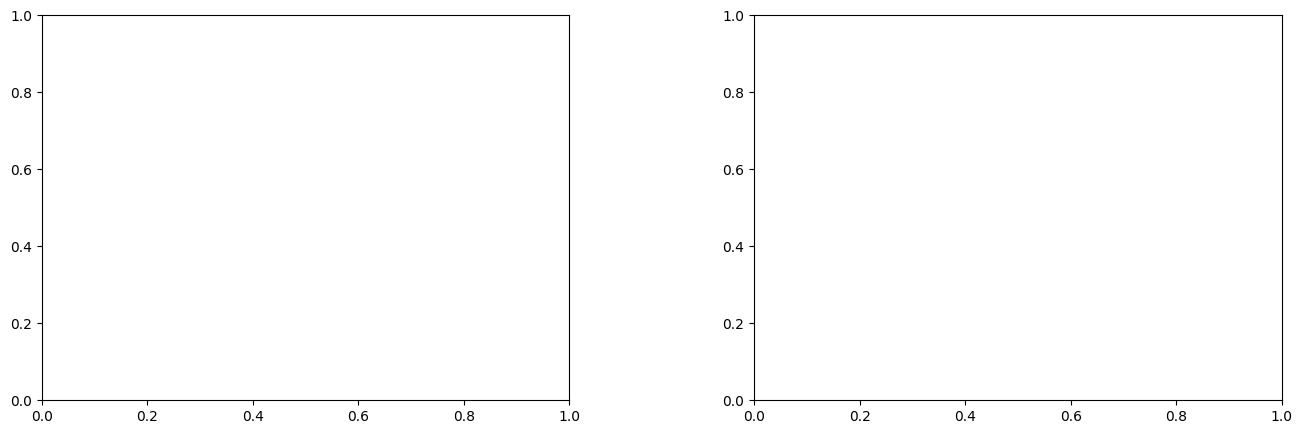

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats as scipy_stats

OPT_COLORS = {
    'phase_aware': '#E74C3C', 'adam': '#3498DB', 'adamw': '#9B59B6',
    'radam': '#1ABC9C', 'lion': '#34495E',
}
OPT_LABELS = {
    'phase_aware': 'PhaseAware (ours)', 'adam': 'Adam',
    'adamw': 'AdamW', 'radam': 'RAdam', 'lion': 'Lion',
}

completed = list(all_results.keys())
N_SEEDS   = len(list(all_results.values())[0])
print(f'Plotting {len(completed)} optimizers: {completed}')

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax_curve = fig.add_subplot(gs[0])
ax_bar   = fig.add_subplot(gs[1])

bar_data = []
for opt_name, runs in all_results.items():
    curves  = np.array([r['history']['val_bleu'] for r in runs])
    mean    = curves.mean(axis=0)
    std     = curves.std(axis=0)
    x       = np.arange(1, len(mean) + 1)
    c       = OPT_COLORS.get(opt_name, '#888')
    lbl     = OPT_LABELS.get(opt_name, opt_name)
    is_ours = opt_name == 'phase_aware'
    ax_curve.plot(x, mean, color=c, lw=2.5 if is_ours else 1.5,
                  linestyle='-' if is_ours else '--', label=lbl,
                  zorder=10 if is_ours else 5)
    ax_curve.fill_between(x, mean - std, mean + std, color=c, alpha=0.12)
    test_bleus = [r['test_bleu'] for r in runs]
    bar_data.append({'name': opt_name, 'label': lbl,
                     'mean': np.mean(test_bleus), 'std': np.std(test_bleus), 'color': c})

ax_curve.set_title('Multi30k En->De -- Val BLEU per epoch', fontsize=11, fontweight='bold')
ax_curve.set_xlabel('Epoch'); ax_curve.set_ylabel('Val BLEU Score')
ax_curve.legend(fontsize=8, loc='lower right'); ax_curve.grid(True, alpha=0.3)
ax_curve.set_xlim(1, None)

bar_data.sort(key=lambda x: x['mean'])
y_pos  = np.arange(len(bar_data))
means  = [d['mean']  for d in bar_data]
stds   = [d['std']   for d in bar_data]
colors = [d['color'] for d in bar_data]
labels = [d['label'] for d in bar_data]
names  = [d['name']  for d in bar_data]

bars = ax_bar.barh(y_pos, means, xerr=stds, color=colors, alpha=0.85,
                   capsize=4, height=0.6, error_kw={'elinewidth': 1.2, 'capthick': 1.2})
for bar, name in zip(bars, names):
    if name == 'phase_aware':
        bar.set_edgecolor('black'); bar.set_linewidth(2)
ax_bar.set_yticks(y_pos); ax_bar.set_yticklabels(labels, fontsize=9)
ax_bar.set_xlabel('Test BLEU Score')
ax_bar.set_title('Multi30k -- Final test BLEU (mean+-std)', fontsize=11, fontweight='bold')
ax_bar.grid(True, axis='x', alpha=0.3)
x_range = ax_bar.get_xlim()[1] - ax_bar.get_xlim()[0]
for i, (m, s) in enumerate(zip(means, stds)):
    ax_bar.text(m + s + x_range*0.005, i, f'{m:.1f}', va='center', fontsize=8.5, fontweight='bold')

fig.suptitle(f'Phase-Aware Optimizer -- Multi30k En->De Translation\n'
             f'Encoder-Decoder Transformer, mean+-std over {N_SEEDS} seeds'
             f' ({len(completed)} optimizers)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/multi30k_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Welch t-test
print('\nStatistical Analysis -- Welch t-test on Test BLEU')
print('=' * 68)
pa_bleu = np.array([r['test_bleu'] for r in all_results['phase_aware']])
print(f'PhaseAware: mean={pa_bleu.mean():.3f}  std={pa_bleu.std():.3f}  n={len(pa_bleu)}\n')
print(f"  {'Baseline':20}  {'Delta':>8}  {'t':>7}  {'p':>9}  {'sig':>5}  95% CI")
print(f"  {'-'*65}")
for name, runs in sorted(all_results.items(),
                          key=lambda x: -np.mean([r['test_bleu'] for r in x[1]])):
    if name == 'phase_aware': continue
    base  = np.array([r['test_bleu'] for r in runs])
    t, p  = scipy_stats.ttest_ind(pa_bleu, base, equal_var=False)
    delta = pa_bleu.mean() - base.mean()
    se    = np.sqrt(pa_bleu.var(ddof=1)/len(pa_bleu) + base.var(ddof=1)/len(base))
    df_d  = ((pa_bleu.var(ddof=1)/len(pa_bleu))**2/(len(pa_bleu)-1) +
             (base.var(ddof=1)/len(base))**2/(len(base)-1))
    ci    = scipy_stats.t.ppf(0.975, max(se**4/df_d, 1e-12)) * se
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    lbl   = OPT_LABELS.get(name, name)
    print(f'  {lbl:20}  {delta:+8.3f}  {t:7.3f}  {p:9.4f}  {sig:>5}  [{delta-ci:+.3f}, {delta+ci:+.3f}]')
print('\n  *** p<0.001  ** p<0.01  * p<0.05  ns=not significant')
print('  Positive Delta = PhaseAware beats the baseline')

from google.colab import files
files.download('/content/multi30k_results.png')

## Analysis -- Training Loss Curves

Shows how quickly each optimizer drives down the cross-entropy loss during training.
A faster-falling loss means the optimizer is more sample-efficient.
The shaded band is +/- 1 std across seeds.

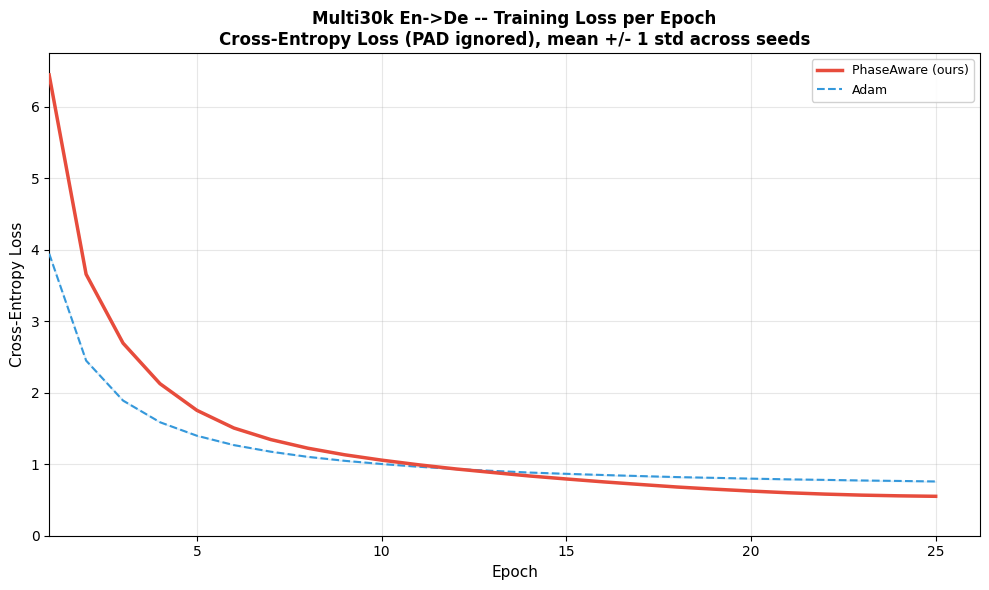

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for opt_name, runs in all_results.items():
    losses  = np.array([r['history']['train_losses'] for r in runs])
    mean    = losses.mean(axis=0)
    std     = losses.std(axis=0)
    x       = np.arange(1, len(mean) + 1)
    c       = OPT_COLORS.get(opt_name, '#888')
    is_ours = opt_name == 'phase_aware'
    ax.plot(x, mean, color=c, lw=2.5 if is_ours else 1.5,
            linestyle='-' if is_ours else '--',
            label=OPT_LABELS.get(opt_name, opt_name),
            zorder=10 if is_ours else 5)
    ax.fill_between(x, mean - std, mean + std, color=c, alpha=0.12)

ax.set_title('Multi30k En->De -- Training Loss per Epoch\n'
             'Cross-Entropy Loss (PAD ignored), mean +/- 1 std across seeds',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, None); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('/content/multi30k_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('/content/multi30k_train_loss.png')

## Analysis -- Example Translations

Qualitative check: shows 10 source sentences from the test set,
the model's translation (HYP), and the reference (REF).

- **SRC** = English input sentence
- **HYP** = German translation produced by the model
- **REF** = Correct human-written German translation

Good for the qualitative analysis section of your paper.

In [ ]:
import warnings; warnings.filterwarnings('ignore')

# PhaseAware config for retraining
PA_CFG = {
    'name': 'phase_aware', 'lr_max': 0.0005, 'lr_min': 2e-5,
    'noise_max': 0.04, 'noise_min': 0.008, 'sam_coeff': 0.015,
    'beta1': 0.9, 'beta1_max': 0.95,
    'weight_decay': 0.01, 'max_grad_norm': 0.5,
    'warmup_ratio': 0.03, 'hold_frac': 0.12,
    'phase_type': 'adaptive', 'var_window': 50, 'time_weight': 0.7,
}

print('Retraining PhaseAware (seed=0) for example translations...')
set_seed(0)
_tr, _vl, _test_l, _sv, _tv = get_multi30k_loaders(
    batch_size=64, src_max=MULTI30K_CFG['src_max'],
    tgt_max=MULTI30K_CFG['tgt_max'], num_workers=2,
)
_demo_model = EncoderDecoderTransformer(
    src_vocab_size=len(_sv), tgt_vocab_size=len(_tv),
    d_model=MULTI30K_CFG.get('d_model', 256), n_heads=MULTI30K_CFG.get('n_heads', 8),
    n_enc_layers=MULTI30K_CFG.get('n_enc_layers', 3),
    n_dec_layers=MULTI30K_CFG.get('n_dec_layers', 3),
    ffn_dim=MULTI30K_CFG.get('ffn_dim', 1024),
    max_len=max(MULTI30K_CFG['src_max'], MULTI30K_CFG['tgt_max']),
).to(device)
_opt  = build_optimizer_seq2seq(PA_CFG, _demo_model, len(_tr) * MULTI30K_CFG['epochs'])
_crit = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD)

for ep in range(1, MULTI30K_CFG['epochs'] + 1):
    loss = train_epoch_seq2seq(_demo_model, _tr, _opt, _crit, device,
                               max_grad_norm=PA_CFG['max_grad_norm'])
    if ep % 5 == 0:
        bleu = eval_epoch_seq2seq(_demo_model, _vl, device, _tv)
        print(f'  Epoch {ep:>2}/{MULTI30K_CFG["epochs"]}  loss={loss:.4f}  val_BLEU={bleu:.2f}')

# Collect 10 test examples
_demo_model.eval()
all_src, all_tgt, all_hyp = [], [], []
for src_b, tgt_b in _test_l:
    src_b = src_b.to(device)
    dec   = _demo_model.greedy_decode(src_b, Vocabulary.SOS, Vocabulary.EOS,
                                      max_len=MULTI30K_CFG['tgt_max'])
    for i in range(src_b.size(0)):
        all_src.append(ids_to_sentence(src_b[i].cpu().tolist(), _sv))
        all_tgt.append(ids_to_sentence(tgt_b[i].tolist(), _tv))
        all_hyp.append(ids_to_sentence(dec[i], _tv))
    if len(all_src) >= 10: break

print()
print('=' * 80)
print('  EXAMPLE TRANSLATIONS -- PhaseAware (seed=0)')
print('  SRC=English input | HYP=Model output | REF=Ground truth German')
print('=' * 80)
for i in range(10):
    print(f'\n  [{i+1}]')
    print(f'  SRC : {all_src[i]}')
    print(f'  HYP : {all_hyp[i]}')
    print(f'  REF : {all_tgt[i]}')
    print(f'  {"-"*76}')

sample_bleu = sb.corpus_bleu(all_hyp[:10], [all_tgt[:10]]).score
full_bleu   = sb.corpus_bleu(all_hyp, [all_tgt]).score
print(f'\n  Sample BLEU (10 sentences) : {sample_bleu:.2f}')
print(f'  Full test  BLEU (1000 sent): {full_bleu:.2f}')
del _demo_model

Retraining PhaseAware (seed=0) for example translations...
[data] Downloading Multi30k from HuggingFace (bentrevett/multi30k)...
[data] Train: 29,000  Val: 1,014  Test: 1,000
[vocab] Building source (English) vocabulary...
[vocab] size=5,970  (added=5,966, dropped 4,557 rare tokens, min_freq=2)
[vocab] Building target (German) vocabulary...
[vocab] size=7,811  (added=7,807, dropped 10,979 rare tokens, min_freq=2)
[data] Src vocab: 5,970  Tgt vocab: 7,811
[data] Src max_len: 64  Tgt max_len: 64


  Epoch  5/25  loss=1.7543  val_BLEU=34.34


  Epoch 10/25  loss=1.0548  val_BLEU=39.36


  Epoch 15/25  loss=0.7932  val_BLEU=39.62


  Epoch 20/25  loss=0.6225  val_BLEU=39.16


  Epoch 25/25  loss=0.5505  val_BLEU=38.91

  EXAMPLE TRANSLATIONS -- PhaseAware (seed=0)
  SRC=English input | HYP=Model output | REF=Ground truth German

  [1]
  SRC : a man in an orange hat starring at something .
  HYP : ein mann mit einem orangefarbenen hut starrt etwas an .
  REF : ein mann mit einem orangefarbenen hut , der etwas <UNK> .
  ----------------------------------------------------------------------------

  [2]
  SRC : a boston terrier is running on lush green grass in front of a white fence .
  HYP : ein boston <UNK> rennt vor einem weißen zaun auf <UNK> grünem gras .
  REF : ein boston terrier läuft über <UNK> gras vor einem weißen zaun .
  ----------------------------------------------------------------------------

  [3]
  SRC : a girl in karate uniform breaking a stick with a front kick .
  HYP : ein mädchen in karateanzügen <UNK> einen stock mit einem tritt einen tritt mit einem tritt auf .
  REF : ein mädchen in einem karateanzug bricht ein brett mit einem trit

## Analysis -- Per-Seed Results Table

Full breakdown of every seed's test BLEU for every optimizer.
Useful for the appendix of your paper to show reproducibility.

In [ ]:
n_seeds      = len(list(all_results.values())[0])
seed_headers = ''.join([f'  Seed {s}' for s in range(n_seeds)])

print('Per-Seed Test BLEU Breakdown -- Multi30k En->De')
print('=' * 75)
print(f"  {'Optimizer':22}{seed_headers}    Mean     Std   Best Val")
print(f"  {'-'*72}")

sorted_results = sorted(
    all_results.items(),
    key=lambda x: -np.mean([r['test_bleu'] for r in x[1]])
)
for name, runs in sorted_results:
    runs_sorted = sorted(runs, key=lambda r: r['seed'])
    test_scores = [r['test_bleu']     for r in runs_sorted]
    best_vals   = [r['best_val_bleu'] for r in runs_sorted]
    lbl         = OPT_LABELS.get(name, name)
    seed_cols   = ''.join([f'  {s:6.2f}' for s in test_scores])
    marker      = '  <-- best' if name == sorted_results[0][0] else ''
    print(f"  {lbl:22}{seed_cols}  "
          f"  {np.mean(test_scores):5.2f}  "
          f"  {np.std(test_scores):4.2f}  "
          f"  {np.mean(best_vals):5.2f}{marker}")
print(f"  {'='*72}")

# Stability ranking
print('\nStability ranking (lowest std = most consistent across seeds):')
print(f"  {'-'*45}")
for rank, (name, runs) in enumerate(
        sorted(all_results.items(), key=lambda x: np.std([r['test_bleu'] for r in x[1]])), 1):
    std = np.std([r['test_bleu'] for r in runs])
    lbl = OPT_LABELS.get(name, name)
    bar = chr(9608) * int(std * 10)
    print(f'  {rank}. {lbl:22}  std={std:.3f}  {bar}')

# Convergence speed
print('\nConvergence speed (epoch when 80% of best val BLEU first reached):')
print(f"  {'-'*50}")
conv_data = []
for name, runs in all_results.items():
    epochs_to_conv = []
    for r in runs:
        curve  = r['history']['val_bleu']
        target = 0.80 * max(curve)
        epoch  = next((i+1 for i, v in enumerate(curve) if v >= target), len(curve))
        epochs_to_conv.append(epoch)
    conv_data.append((name, np.mean(epochs_to_conv), np.std(epochs_to_conv)))
conv_data.sort(key=lambda x: x[1])
for name, mean_ep, std_ep in conv_data:
    lbl = OPT_LABELS.get(name, name)
    bar = chr(9608) * int(mean_ep)
    print(f'  {lbl:22}  epoch {mean_ep:4.1f} +/- {std_ep:.1f}  {bar}')
print('\nNote: lower epoch = faster convergence = more sample-efficient')

Per-Seed Test BLEU Breakdown -- Multi30k En->De
  Optimizer               Seed 0  Seed 1  Seed 2    Mean     Std   Best Val
  ------------------------------------------------------------------------
  PhaseAware (ours)        36.47   37.14   37.28    36.96    0.35    39.49  <-- best
  Adam                     35.42   36.76   36.54    36.24    0.58    38.61

Stability ranking (lowest std = most consistent across seeds):
  ---------------------------------------------
  1. PhaseAware (ours)       std=0.351  ███
  2. Adam                    std=0.585  █████

Convergence speed (epoch when 80% of best val BLEU first reached):
  --------------------------------------------------
  Adam                    epoch  3.0 +/- 0.0  ███
  PhaseAware (ours)       epoch  4.3 +/- 0.5  ████

Note: lower epoch = faster convergence = more sample-efficient
